In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)
plt.style.use("default")

DATA_PATH = Path("../datasets/processed/ads_model_v1.csv")
df = pd.read_csv(DATA_PATH)

df.shape


(39301, 73)

In [3]:
df.head(5).T


,0,1,2,3,4
target_price_kzt,17500000,25000000,22000000,25500000,17000000
area_m2,29.00,42.70,27.00,55.60,48.00
rooms,1,2,1,2,2
lat,43.29,43.34,43.33,43.25,43.34
lon,76.83,76.95,77.03,76.81,76.97
...,...,...,...,...,...
universities_mean_dist_km_5,7.43,7.11,8.36,4.47,6.95
district,Alatauskiy_r-n,Turksibskiy_r-n,Medeuskiy_r-n,Alatauskiy_r-n,Turksibskiy_r-n
house_type,монолитный,кирпичный,монолитный,монолитный,кирпичный
condition,свежий ремонт,свежий ремонт,свежий ремонт,свободная планировка,"не новый, но аккуратный ремонт"


In [4]:
column_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "unique_count": df.nunique(dropna=True),
})

column_summary.sort_values(["missing_pct", "unique_count"], ascending=[False, False])


,dtype,missing_count,missing_pct,unique_count
ceiling_height_m,float64,37199,94.65,40
floors_total,float64,1221,3.11,36
floor_current,float64,1221,3.11,32
dentistry_dist_km_1,float64,0,0.00,21746
hospitals_dist_km_1,float64,0,0.00,21746
...,...,...,...,...
transport_count_1000m,int64,0,0.00,3
has_photo,float64,0,0.00,2
has_complex_id,int64,0,0.00,2
has_microdistrict,int64,0,0.00,2


In [5]:
checks = pd.Series({
    "rows": len(df),
    "columns": df.shape[1],
    "target_min_kzt": df["target_price_kzt"].min(),
    "target_median_kzt": df["target_price_kzt"].median(),
    "target_max_kzt": df["target_price_kzt"].max(),
})

checks


rows                       39,301.00
columns                        73.00
target_min_kzt          2,000,000.00
target_median_kzt      42,000,000.00
target_max_kzt      1,700,000,000.00
dtype: float64

In [6]:
missing_summary = (
    column_summary[column_summary["missing_count"] > 0]
    .sort_values("missing_pct", ascending=False)
)

missing_summary


,dtype,missing_count,missing_pct,unique_count
ceiling_height_m,float64,37199,94.65,40
floor_current,float64,1221,3.11,32
floors_total,float64,1221,3.11,36


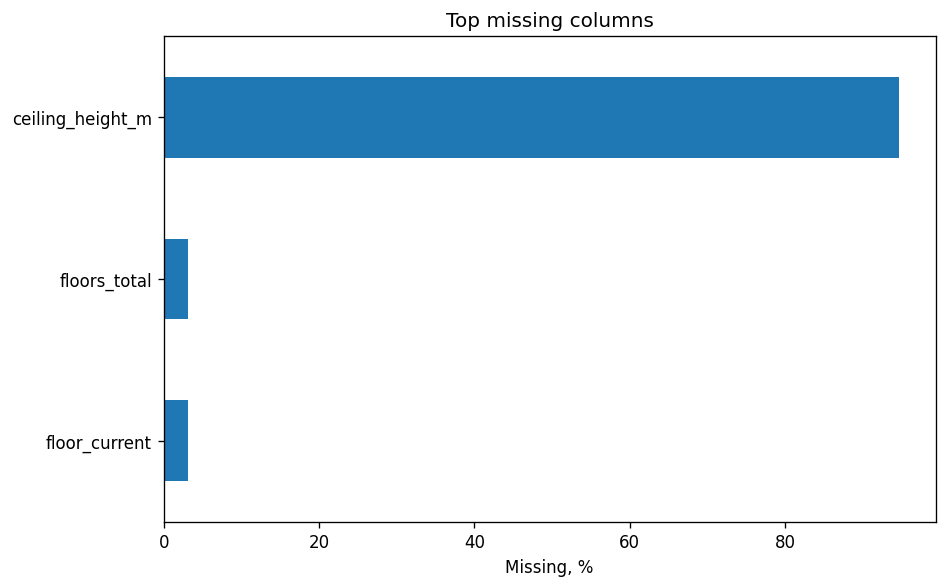

In [6]:
top_missing = missing_summary.head(20).sort_values("missing_pct")

fig, ax = plt.subplots(figsize=(8, 5))
top_missing["missing_pct"].plot(kind="barh", ax=ax)
ax.set_title("Top missing columns")
ax.set_xlabel("Missing, %")
ax.set_ylabel("")
fig.tight_layout()


In [7]:
main_numeric_cols = [
    "target_price_kzt",
    "area_m2",
    "rooms",
    "year_built",
    "floor_current",
    "floors_total",
    "ceiling_height_m",
    "photo_count",
    "complex_listing_count",
]

df[main_numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
target_price_kzt,"39,301.00","60,062,843.91","64,702,099.82","2,000,000.00","31,000,000.00","42,000,000.00","65,000,000.00","1,700,000,000.00"
area_m2,"39,301.00",69.26,43.84,2.00,44.00,59.60,80.00,999.00
rooms,"39,301.00",2.27,1.01,1.00,2.00,2.00,3.00,12.00
year_built,"39,301.00","2,005.85",20.54,"1,850.00","1,987.00","2,016.00","2,022.00","2,028.00"
floor_current,"38,080.00",5.35,3.95,1.00,2.00,4.00,7.00,36.00
floors_total,"38,080.00",8.98,4.89,1.00,5.00,9.00,12.00,100.00
ceiling_height_m,"2,102.00",2.98,2.90,2.00,2.70,2.80,3.00,100.00
photo_count,"39,301.00",13.67,10.31,0.00,7.00,12.00,18.00,100.00
complex_listing_count,"39,301.00",52.64,82.08,0.00,0.00,9.00,74.00,446.00


In [8]:
categorical_cols = ["district", "house_type", "condition", "bathroom_type"]

categorical_summary = pd.DataFrame({
    "missing": df[categorical_cols].isna().sum(),
    "unique": df[categorical_cols].nunique(dropna=True),
    "top": [df[col].mode(dropna=True).iat[0] for col in categorical_cols],
    "top_count": [df[col].value_counts(dropna=True).iloc[0] for col in categorical_cols],
})

categorical_summary


,missing,unique,top,top_count
district,0,9,Bostandykskiy_r-n,10119
house_type,0,5,монолитный,25192
condition,0,6,unknown,14741
bathroom_type,0,5,unknown,20771


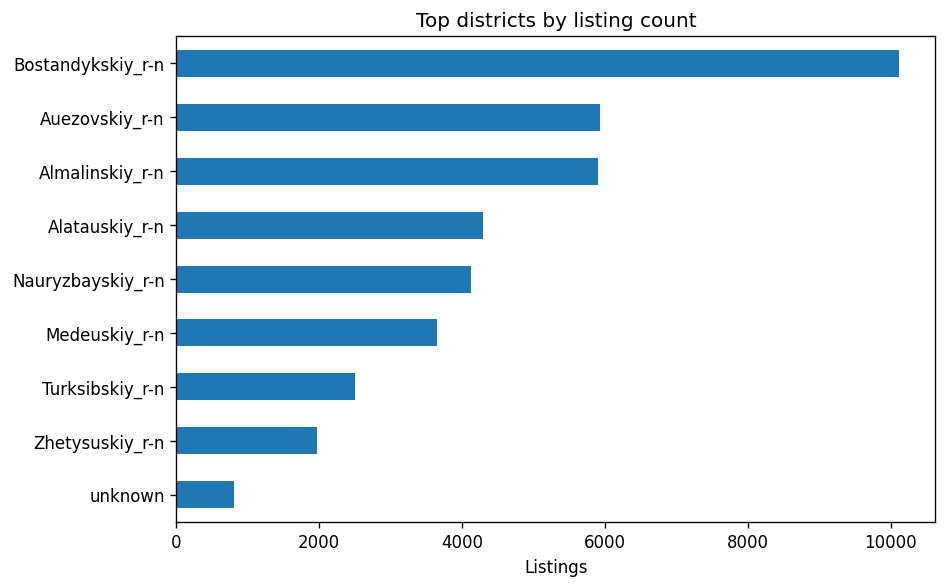

In [9]:
district_counts = df["district"].value_counts().head(12).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
district_counts.plot(kind="barh", ax=ax)
ax.set_title("Top districts by listing count")
ax.set_xlabel("Listings")
ax.set_ylabel("")
fig.tight_layout()


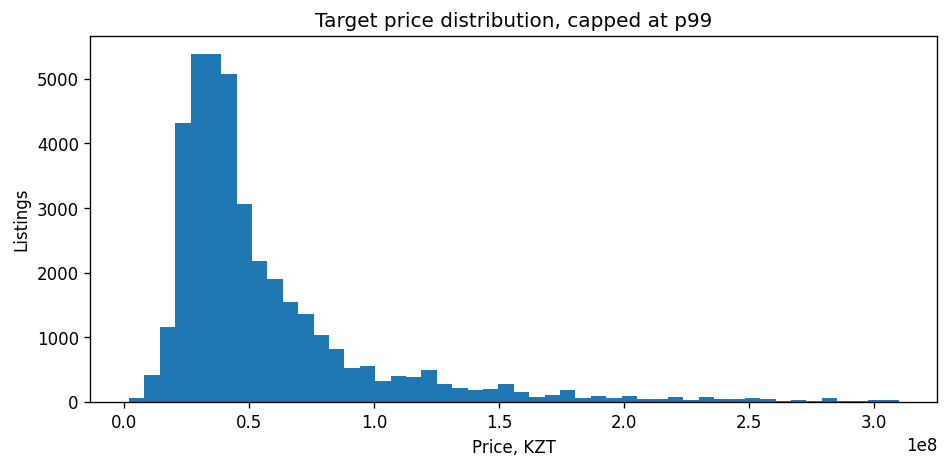

In [10]:
price_cap = df["target_price_kzt"].quantile(0.99)
price_for_plot = df.loc[df["target_price_kzt"] <= price_cap, "target_price_kzt"]

fig, ax = plt.subplots(figsize=(8, 4))
price_for_plot.plot(kind="hist", bins=50, ax=ax)
ax.set_title("Target price distribution, capped at p99")
ax.set_xlabel("Price, KZT")
ax.set_ylabel("Listings")
fig.tight_layout()


In [11]:
district_price = (
    df.groupby("district")
    .agg(
        listings=("target_price_kzt", "size"),
        median_price_kzt=("target_price_kzt", "median"),
        median_area_m2=("area_m2", "median"),
    )
    .sort_values("median_price_kzt", ascending=False)
)

district_price


,listings,median_price_kzt,median_area_m2
district,,,
Medeuskiy_r-n,3641,"66,000,000.00",73.00
Bostandykskiy_r-n,10119,"65,000,000.00",69.40
Almalinskiy_r-n,5907,"45,000,000.00",58.00
unknown,809,"44,000,000.00",58.00
Auezovskiy_r-n,5927,"39,900,000.00",58.00
Nauryzbayskiy_r-n,4130,"34,500,000.00",57.85
Alatauskiy_r-n,4296,"32,000,000.00",50.95
Turksibskiy_r-n,2500,"30,175,000.00",50.00
Zhetysuskiy_r-n,1972,"30,000,000.00",47.45


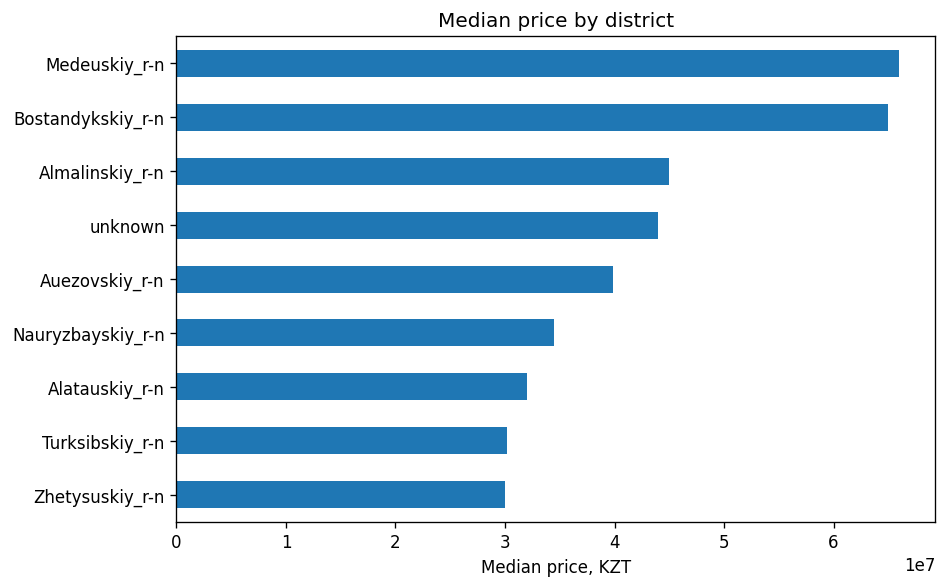

In [12]:
district_price_for_plot = district_price.sort_values("median_price_kzt")

fig, ax = plt.subplots(figsize=(8, 5))
district_price_for_plot["median_price_kzt"].plot(kind="barh", ax=ax)
ax.set_title("Median price by district")
ax.set_xlabel("Median price, KZT")
ax.set_ylabel("")
fig.tight_layout()


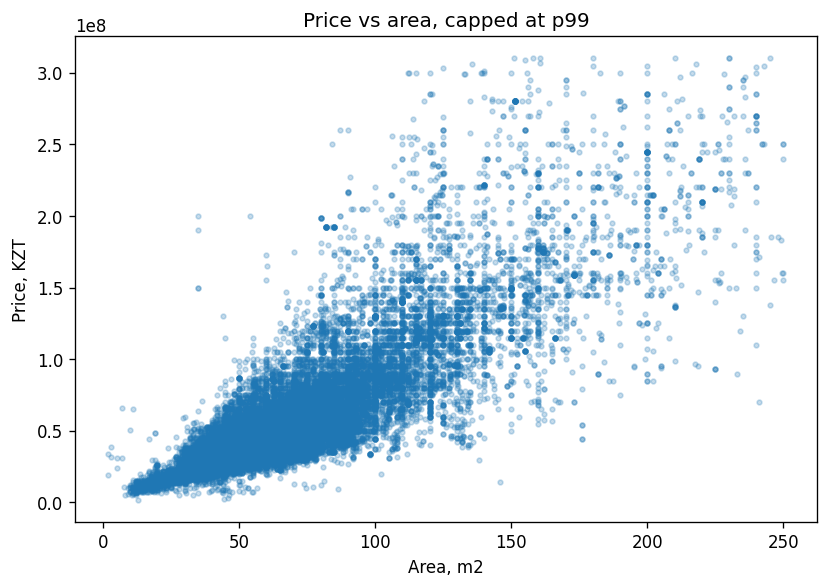

In [13]:
area_cap = df["area_m2"].quantile(0.99)
scatter_df = df[(df["area_m2"] <= area_cap) & (df["target_price_kzt"] <= price_cap)]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(scatter_df["area_m2"], scatter_df["target_price_kzt"], s=8, alpha=0.25)
ax.set_title("Price vs area, capped at p99")
ax.set_xlabel("Area, m2")
ax.set_ylabel("Price, KZT")
fig.tight_layout()


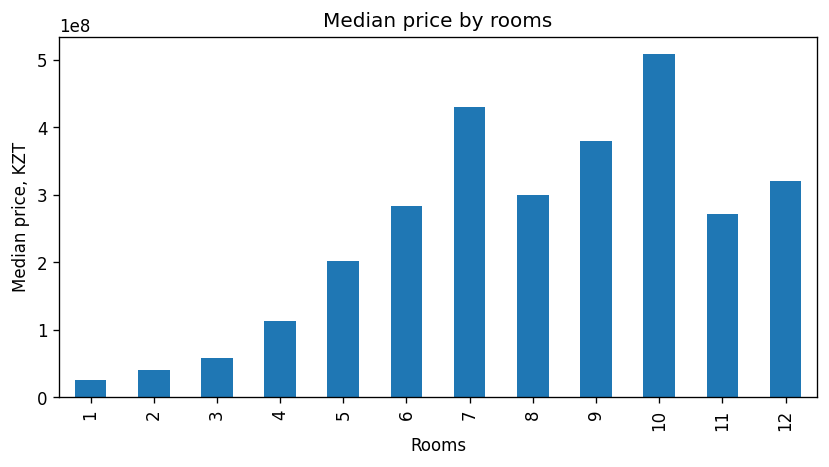

In [14]:
room_price = df.groupby("rooms")["target_price_kzt"].median().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
room_price.plot(kind="bar", ax=ax)
ax.set_title("Median price by rooms")
ax.set_xlabel("Rooms")
ax.set_ylabel("Median price, KZT")
fig.tight_layout()


In [15]:
corr_with_target = (
    df.select_dtypes("number")
    .corr(numeric_only=True)["target_price_kzt"]
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .to_frame("corr_with_target")
)

corr_with_target.head(20)


,corr_with_target
target_price_kzt,1.00
area_m2,0.81
rooms,0.58
photo_count,0.33
lat,-0.27
transport_mean_dist_km_5,0.26
has_complex_id,0.24
universities_mean_dist_km_5,-0.24
transport_mean_dist_km_3,0.23
universities_mean_dist_km_3,-0.22


In [16]:
notes = [
    f"Rows: {len(df):,}; columns: {df.shape[1]:,}.",
    f"Full duplicate rows: {df.duplicated().sum():,}.",
    f"Median target price: {df['target_price_kzt'].median():,.0f} KZT.",
    f"Median area: {df['area_m2'].median():,.1f} m2.",
    f"Most common district: {df['district'].mode(dropna=True).iat[0]}.",
]

for note in notes:
    print(f"- {note}")


- Rows: 39,301; columns: 73.
- Full duplicate rows: 1,230.
- Median target price: 42,000,000 KZT.
- Median area: 59.6 m2.
- Most common district: Bostandykskiy_r-n.
